In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('car data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [4]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [5]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

# Data Preprocessing

In [6]:
df['Year'].value_counts()

2015    61
2016    50
2014    38
2017    35
2013    33
2012    23
2011    19
2010    15
2008     7
2009     6
2006     4
2005     4
2003     2
2007     2
2018     1
2004     1
Name: Year, dtype: int64

In [7]:
df['Age_of_car'] = 2022 - df['Year']


In [8]:
df.drop('Year',axis = 1,inplace = True)

In [9]:
df.head()

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age_of_car
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,8
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,9
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,5
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,11
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,8


# Data Preprocessing

In [10]:
df.rename(columns = {'Selling_Price':'Selling_Price(lacs)','Present_Price':'Present_Price(lacs)','Owner':'Past_Owners'},inplace = True)

In [11]:
df.columns

Index(['Car_Name', 'Selling_Price(lacs)', 'Present_Price(lacs)', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Past_Owners',
       'Age_of_car'],
      dtype='object')

In [12]:
num_cols = ['Selling_Price(lacs)','Present_Price(lacs)','Kms_Driven','Age']
cat_cols = ['Fuel_Type','Seller_Type','Transmission','Past_Owners']

<AxesSubplot:xlabel='Fuel_Type', ylabel='count'>

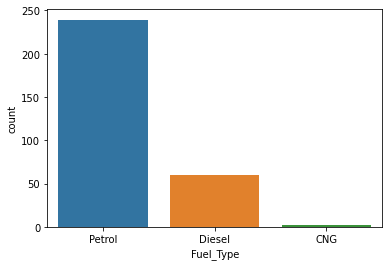

In [13]:
sns.countplot(x='Fuel_Type',data = df)

<AxesSubplot:xlabel='Seller_Type', ylabel='count'>

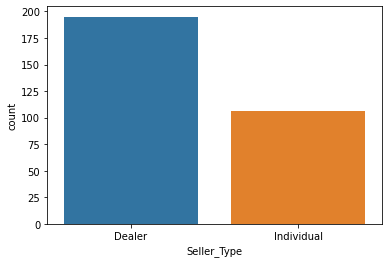

In [14]:
sns.countplot(x='Seller_Type',data=df)

<AxesSubplot:xlabel='Transmission', ylabel='count'>

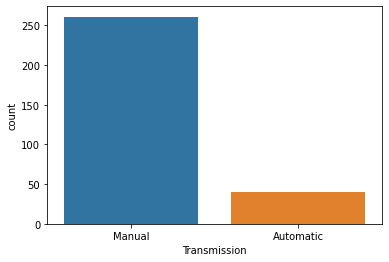

In [15]:
sns.countplot(x='Transmission',data = df)

In [16]:
df.corr()['Selling_Price(lacs)']

Selling_Price(lacs)    1.000000
Present_Price(lacs)    0.878983
Kms_Driven             0.029187
Past_Owners           -0.088344
Age_of_car            -0.236141
Name: Selling_Price(lacs), dtype: float64

In [17]:
df.drop('Car_Name',axis = 1,inplace= True)

In [18]:
df.head()

,Selling_Price(lacs),Present_Price(lacs),Kms_Driven,Fuel_Type,Seller_Type,Transmission,Past_Owners,Age_of_car
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,8
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,9
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,5
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,11
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,8


In [19]:
df = pd.get_dummies(df,drop_first = True)
df.head()

,Selling_Price(lacs),Present_Price(lacs),Kms_Driven,Past_Owners,Age_of_car,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,8,0,1,0,1
1,4.75,9.54,43000,0,9,1,0,0,1
2,7.25,9.85,6900,0,5,0,1,0,1
3,2.85,4.15,5200,0,11,0,1,0,1
4,4.60,6.87,42450,0,8,1,0,0,1


# Train_Test_Split

In [20]:
X = df.drop('Selling_Price(lacs)',axis = 1)
y = df['Selling_Price(lacs)']

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [22]:
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

In [23]:
CV = []
R2_train = []
R2_test = []

def car_pred_model(model,model_name):
    # Training model
    model.fit(X_train,y_train)
            
    # R2 score of train set
    y_pred_train = model.predict(X_train)
    R2_train_model = r2_score(y_train,y_pred_train)
    R2_train.append(round(R2_train_model,2))
    
    # R2 score of test set
    y_pred_test = model.predict(X_test)
    R2_test_model = r2_score(y_test,y_pred_test)
    R2_test.append(round(R2_test_model,2))
    
     # R2 mean of train set using Cross validation
    cross_val = cross_val_score(model ,X_train ,y_train ,cv=5)
    cv_mean = cross_val.mean()
    CV.append(round(cv_mean,2))
    
    # Printing results
    print("Train R2-score :",round(R2_train_model,2))
    print("Test R2-score :",round(R2_test_model,2))
    print("Train CV scores :",cross_val)
    print("Train CV mean :",round(cv_mean,2))
    
    

# Linear Regression

In [24]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
car_pred_model(lr,"Linear_regressor.pkl")

Train R2-score : 0.88
Test R2-score : 0.86
Train CV scores : [0.89912189 0.89838688 0.82980069 0.81769076 0.76113925]
Train CV mean : 0.84


# Lasso Regression

In [25]:
from sklearn.linear_model import Lasso
lasso_model = Lasso()
car_pred_model(lasso_model,"Lasso_regressor.pkl")



Train R2-score : 0.84
Test R2-score : 0.85
Train CV scores : [0.84071746 0.87433942 0.79489308 0.79546381 0.66739023]
Train CV mean : 0.79


# Ridge Regression

In [26]:
from sklearn.linear_model import Ridge
ridge_model = Ridge()
car_pred_model(ridge_model,"Ridge_regressor.pkl")

Train R2-score : 0.88
Test R2-score : 0.86
Train CV scores : [0.89874551 0.89917784 0.83132857 0.81902498 0.75750692]
Train CV mean : 0.84


# Random Forest

In [27]:
from sklearn.ensemble import RandomForestRegressor
rmodel = RandomForestRegressor()
car_pred_model(rmodel,"Random_Forest.pkl")



Train R2-score : 0.98
Test R2-score : 0.89
Train CV scores : [0.9304771  0.96803883 0.86284648 0.936411   0.73615893]
Train CV mean : 0.89


# Gradiant boost

In [28]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model = GradientBoostingRegressor()
car_pred_model(gb_model,"Gradient boost.pkl")

Train R2-score : 1.0
Test R2-score : 0.94
Train CV scores : [0.94237623 0.93749089 0.89873047 0.93427953 0.75943364]
Train CV mean : 0.89


# price prediction

In [29]:
df = pd.get_dummies(df, drop_first=True)

In [30]:
import joblib

joblib.dump(lr, "car_price_model.pkl")   # best model
joblib.dump(X.columns, "features.pkl")         # save column names

['features.pkl']